# Overview of WP1 Glaciers

In [1]:
# imports
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path

import shapely
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Rectangle, Circle
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm, Normalize
import matplotlib.transforms as transforms
from matplotlib import cm


In [2]:
plt.rcParams.update({
    'font.size': 14,          # Default font size for all text
    'axes.titlesize': 14,     # Font size for axes titles
    'axes.labelsize': 14,     # Font size for axes labels
    'xtick.labelsize': 14,    # Font size for x-axis tick labels
    'ytick.labelsize': 14,    # Font size for y-axis tick labels
    'legend.fontsize': 14,    # Font size for legend
    'figure.titlesize': 16,   # Font size for figure title
    'font.family': 'sans-serif',   # Font family (e.g., 'serif', 'sans-serif')
    'axes.labelweight': 'bold',  # Weight for axes labels
    'axes.titleweight': 'bold',  # Weight for axes titles
    'legend.title_fontsize': '12', # Font size for legend title
})

### Glacier data and statistics

In [3]:
# load glacier outlines
rgi_glac_gdf_dict = {}
for i in range(19):
    rgi_glac_dir = Path('/Users/albwel/data/rgi70/glaciers')
    rgi_str = str(i+1).zfill(2)
    rgi_glac_fold = [d for d in rgi_glac_dir.iterdir() if d.is_dir() and d.name.startswith(f'RGI2000-v7.0-G-{rgi_str}')][0]
    rgi_glac_fp = rgi_glac_fold / f'{rgi_glac_fold.name}.shp'
    rgi_glac_gdf = gpd.read_file(rgi_glac_fp)
    rgi_glac_gdf = rgi_glac_gdf[rgi_glac_gdf['area_km2'] > 2]
    rgi_glac_gdf.to_crs('EPSG:4326', inplace=True)
    rgi_glac_gdf_dict[rgi_str] = rgi_glac_gdf
    

In [18]:
info_dict = {'Hofsjökull': {'reg': 6, 'lat': 64.81793129969515, 'lon': -18.818888990694262, },
             'Hansbreen': {'reg': 7, 'lat': 77.08146610844912, 'lon': 15.639770570606167, },
             'Hellstugubreen': {'reg': 8, 'lat': 61.53969044612334, 'lon': 8.448245986146087, },
             'Aletsch': {'reg': 11, 'lat': 46.489263479951376, 'lon': 8.052991821123078, },
             'Argentière': {'reg': 11, 'lat': 45.944513739597, 'lon': 6.994728292728016, },
             'Gepatschferner': {'reg': 11, 'lat': 46.85145078740811, 'lon': 10.749652740327603, },
             'Zongo': {'reg': 16, 'lat': -16.277202380192296, 'lon': -68.1434100958808, },
             'Brewster': {'reg': 18, 'lat': -44.08299323582714, 'lon': 169.43316158833662, },
            }
# note: lat/lon are approximate (sometimes near terminus, sometimes near centroid); they are just based on Google

lab_dict = {'Aletsch':        {'loc': (0.25, 0.73), 'ha': 'right','d1': 0.086, 'd2': 0.086, 'l1': -0.10, 'l2': -0.00},
            'Hofsjökull':     {'loc': (0.40, 0.85), 'ha': 'right','d1': 0.058, 'd2': 0.062, 'l1': -0.40, 'l2': -0.05},
            'Hansbreen':      {'loc': (0.60, 0.85), 'ha': 'left', 'd1': 0.065, 'd2': 0.063, 'l1': -0.05, 'l2': -0.47},
            'Hellstugubreen': {'loc': (0.75, 0.73), 'ha': 'left', 'd1': 0.088, 'd2': 0.088, 'l1': -0.02, 'l2': -0.07},
            'Zongo':          {'loc': (0.20, 0.50), 'ha': 'right','d1': 0.082, 'd2': 0.082, 'l1': -0.20, 'l2': -0.05},
            'Argentière':     {'loc': (0.45, 0.35), 'ha': 'right','d1': 0.061, 'd2': 0.061, 'l1': 0.00, 'l2': -0.10},
            'Gepatschferner': {'loc': (0.65, 0.35), 'ha': 'left', 'd1': 0.064, 'd2': 0.064, 'l1': -0.14, 'l2': 0.01},
            'Brewster':       {'loc': (0.80, 0.50), 'ha': 'left', 'd1': 0.049, 'd2': 0.047, 'l1': -0.35, 'l2': -0.40},
            }
# lab_dict = {'Aletsch':        {'loc': (0.37, 0.60), 'ha': 'right','d1': 0.081, 'd2': 0.087, 'l1': -0.05, 'l2': -0.20},
#             'Hofsjokull':     {'loc': (0.40, 0.85), 'ha': 'right','d1': 0.058, 'd2': 0.062, 'l1': -0.40, 'l2': -0.05},
#             'Hansbreen':      {'loc': (0.60, 0.85), 'ha': 'left', 'd1': 0.065, 'd2': 0.063, 'l1': -0.05, 'l2': -0.47},
#             'Hellstugubreen': {'loc': (0.75, 0.73), 'ha': 'left', 'd1': 0.089, 'd2': 0.090, 'l1': 0.00, 'l2': -0.05},
#             'Zongo':          {'loc': (0.25, 0.50), 'ha': 'right','d1': 0.074, 'd2': 0.075, 'l1': -0.38, 'l2': -0.10},
#             'Argentiere':     {'loc': (0.45, 0.35), 'ha': 'right','d1': 0.061, 'd2': 0.061, 'l1': 0.00, 'l2': -0.10},
#             'Gepatschferner': {'loc': (0.65, 0.35), 'ha': 'left', 'd1': 0.064, 'd2': 0.064, 'l1': -0.14, 'l2': 0.01},
#             'Brewster':       {'loc': (0.80, 0.50), 'ha': 'left', 'd1': 0.049, 'd2': 0.047, 'l1': -0.35, 'l2': -0.40},
#             }

scale_dict = {'Aletsch':        {'loc': (-0.35, -0.25), 'l': 5, 'a_class': 1, 'rgi_sf': 1.25},
              'Hofsjökull':     {'loc': (0.28, -0.40), 'l': 10, 'a_class': 2, 'rgi_sf': 1.15},
              'Hansbreen':      {'loc': (0.20, 0.45), 'l': 10, 'a_class': 2, 'rgi_sf': 1.20},
              'Hellstugubreen': {'loc': (-0.30, 0.50), 'l': 1, 'a_class': 1, 'rgi_sf': 1.19},
              'Zongo':          {'loc': (-0.04, 0.44), 'l': 1, 'a_class': 0, 'rgi_sf': 1.07},
              'Argentière':     {'loc': (-0.25, 0.50), 'l': 5, 'a_class': 1, 'rgi_sf': 0.99},
              'Gepatschferner': {'loc': (-0.25, 0.55), 'l': 1, 'a_class': 1, 'rgi_sf': 1.09},
              'Brewster':       {'loc': (0.15, -0.25), 'l': 1, 'a_class': 0, 'rgi_sf': 1.10},
              }

dir_fp = '/Users/albwel/Desktop/ContinuIX_WP1/ContinuIX_WP1/outlines/'
outline_dict = {'Hofsjökull': 'outline_Hofsjokull_RGIv6_4326.shp',
                'Hansbreen': 'hansbreen_outline_rgi6.shp', #CHANGE
                'Hellstugubreen': 'dren2019_mb.shp',
                'Aletsch': 'outline_Aletsch_RGIv6_4326.shp',
                'Argentière': 'argentiere_outline_20200908.shp',
                'Gepatschferner': 'gepatsch_outline_2023.geojson',
                'Zongo': 'Zongo_Outline-2013.shp',
                'Brewster': 'brewster_outline_rgi6.shp',#CHANGE
                }

# glacier characteristics
    # type: valley, cirque, tidewater, ice cap
chars_dict = {'Aletsch':        {'type': 'v',  'surge': 0, 'temperate': 1},
              'Hofsjökull':     {'type': 'ic', 'surge': 1, 'temperate': 1},
              'Hansbreen':      {'type': 'tw', 'surge': 1, 'temperate': 1},
              'Hellstugubreen': {'type': 'v',  'surge': 0, 'temperate': 1},
              'Zongo':          {'type': 'v',  'surge': 0, 'temperate': 0},
              'Argentière':     {'type': 'v',  'surge': 0, 'temperate': 1},
              'Gepatschferner': {'type': 'v',  'surge': 0, 'temperate': 1},
              'Brewster':       {'type': 'c',  'surge': 0, 'temperate': 1},
              }

# for each dataset (h, v, dh, smb, a) indicate coverage (full, part, none) 
    # [thickness, vel, elevation change, stakes, outlines]
datasets_dict = {'Aletsch':        {'h': ('full', 1), 'v': ('full', 9), 'dh': ('full', 1), 'smb': ('full', 26), 'a': ('full', 1)}, # done
                 'Hofsjökull':     {'h': ('full', 1), 'v': ('full', 10), 'dh': ('full', 2), 'smb': ('full', 37), 'a': ('full', 1)}, # done
                 'Hansbreen':      {'h': ('none', 0), 'v': ('full', 16), 'dh': ('none', 0), 'smb': ('full', 14), 'a': ('full', 1)},
                 'Hellstugubreen': {'h': ('full', 1), 'v': ('none', 0), 'dh': ('full', 1), 'smb': ('full', 63), 'a': ('full', 2)}, # done
                 'Zongo':          {'h': ('full', 1), 'v': ('full', 1), 'dh': ('full', 1), 'smb': ('full', 7), 'a': ('full', 2)}, # done
                 'Argentière':     {'h': ('full', 1), 'v': ('full', 1), 'dh': ('part', 1), 'smb': ('full', 10), 'a': ('full', 2)}, # done
                 'Gepatschferner': {'h': ('full', 1), 'v': ('none', 0), 'dh': ('full', 1), 'smb': ('full', 16), 'a': ('full', 6)}, # done
                 'Brewster':       {'h': ('full', 3), 'v': ('full', 1), 'dh': ('full', 1), 'smb': ('full', 11), 'a': ('full', 2)},
                }

# Gepatsch: stake velocity
# Hellstugubreen: smb is not point data (at the moment); stake velocity
# NOTE: Brewster and Hansbreen we haven't gotten the data yet
        # Hansbreen has repeat velocity at stakes with good coverage



In [19]:
def coordXform(orig_crs, target_crs, x, y):
    return target_crs.transform_points(orig_crs, x, y)

def perp_points(p1, p2, d1, d2, l1=0.0, l2=0.0):
    """
    Calculates two points perpendicular to the line segment p1→p2, 
    with independent distances and optional forward/backward offsets.

    Parameters
    ----------
    p1 : (x, y)
    p2 : (x, y)
    d1 : distance on one side of the perpendicular
    d2 : distance on the other side
    l1 : fraction of |p2 - p1| to move along the line for point 1 (default 0)
    l2 : fraction of |p2 - p1| to move along the line for point 2 (default 0)

    Returns
    -------
    p3, p4 : tuple
        Two points on opposite sides of the perpendicular through p2
    """
    p1 = np.array(p1, dtype=float)
    p2 = np.array(p2, dtype=float)

    v = p2 - p1
    v_norm = v / np.linalg.norm(v)

    # perpendicular unit vector
    v_perp = np.array([-v[1], v[0]])
    v_perp_norm = v_perp / np.linalg.norm(v_perp)

    # apply perpendicular + optional along-line shift
    p3 = p2 + v_perp_norm * d1 + v_norm * (l1 * np.linalg.norm(v))
    p4 = p2 - v_perp_norm * d2 + v_norm * (l2 * np.linalg.norm(v))

    return tuple(p3), tuple(p4)
    

### Plot results

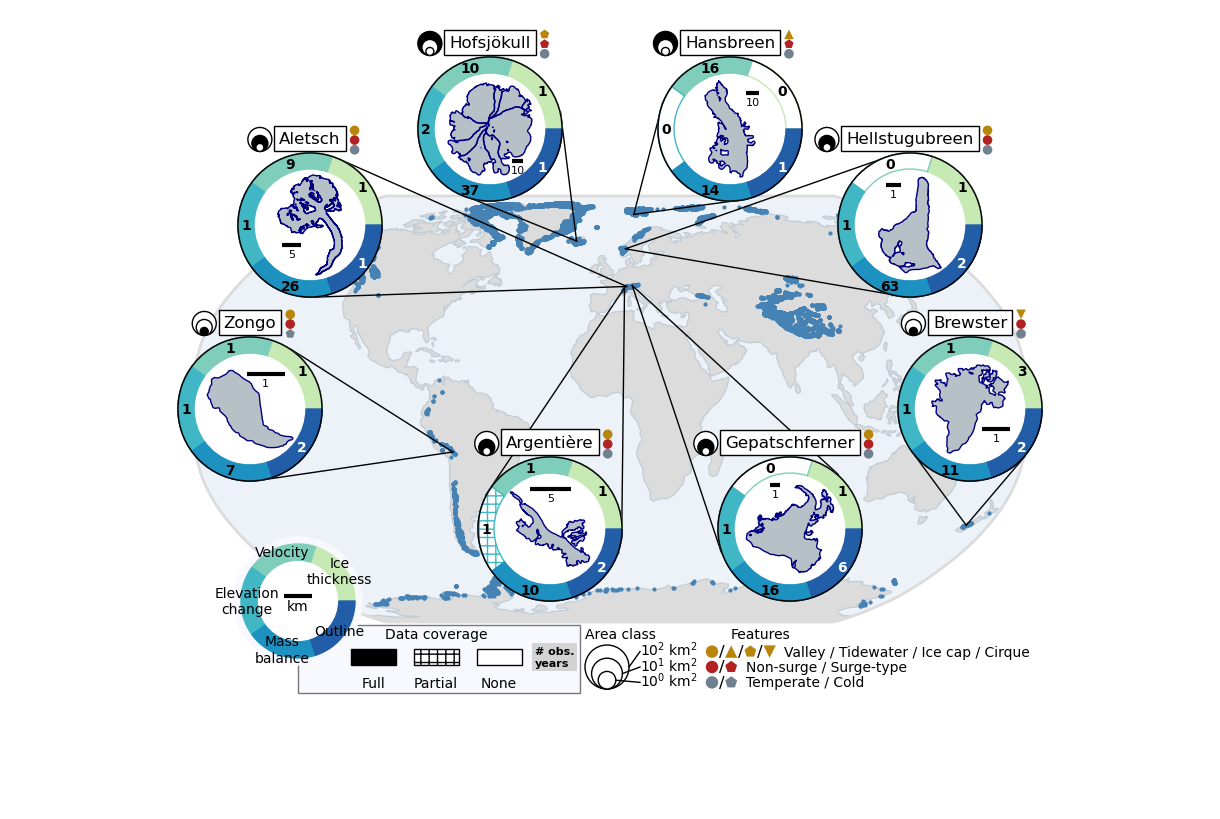

In [23]:
fig = plt.figure(figsize=(12, 8))

# glob_ccrs = ccrs.epsg(3857)
glob_ccrs = ccrs.Robinson() #ccrs.PlateCarree()

# Make map smaller and centered
ax_map = fig.add_axes([0.15, 0.2, 0.7, 0.6], projection=glob_ccrs)
# ax_map = fig.add_axes([0,0,1,1], projection=glob_ccrs)
ax_map.set_global()
ax_map.add_feature(cfeature.LAND, alpha=1, color='gainsboro')
ax_map.add_feature(cfeature.OCEAN, alpha=0.1, color='steelblue')
ax_map.spines['geo'].set_edgecolor('gainsboro')
ax_map.spines['geo'].set_linewidth(2)
ax_map.spines['geo'].set_zorder(10)
ax_map.set_zorder(0)

# add RGI glacier outlines
for rgi_str, gdf in rgi_glac_gdf_dict.items():
    gdf["geometry"] = gdf["geometry"].apply(lambda g: shapely.wkb.loads(shapely.wkb.dumps(g, output_dimension=2)))
    gdf = gdf[gdf.geometry.notnull()]
    gdf = gdf[~gdf.geometry.is_empty]
    gdf = gdf[gdf.is_valid]

    # # ax_map.add_geometries(gdf.geometry, crs=ccrs.PlateCarree(),
    # #                       facecolor='none', edgecolor='darkgrey', lw=1.5, zorder=4)
    # ax_map.add_geometries(gdf.geometry, crs=ccrs.PlateCarree(),
    #                       facecolor='none', edgecolor='steelblue', lw=1.5, zorder=4)
    ax_map.scatter(gdf['cenlon'], gdf['cenlat'], transform=ccrs.PlateCarree(), color='steelblue', s=4, zorder=4)

# --------------------------------- full outline ax ---------------------------------
ax_full = fig.add_axes([0, 0, 1, 1])
ax_full.set_axis_off()
ax_full.patch.set_alpha(0.0)
ax_full.set_xlim(0, 1)
ax_full.set_ylim(0, 1)
ax_full.set_clip_on(False)
ax_full.set_zorder(1)

# --------------------------------- ----------- circular subplots ----------- -------------------------------
# draw each ring as a wedge
connect_line_c = 'k'
connect_lw = 1

glacs_plot = lab_dict.keys()

glac_ax = {}
for glac in glacs_plot: 
    p = lab_dict[glac]['loc']

    # add axis
    ax_size = 0.2
    ax = fig.add_axes([p[0] - (ax_size/2), p[1] - (ax_size/2), ax_size, ax_size])
    ax.set_zorder(2)
    glac_ax[glac] = ax

    # --- force circular clipping region ---
    clip_circle = Circle((0, 0), 1.0, transform=ax.transData)
    ax.set_clip_path(clip_circle)

    # --- glacier geometry (ignore CRS issues, just make it visible) ---
    shp_fp = outline_dict[glac]
    shp_df = gpd.read_file(dir_fp + shp_fp)
    shp_df.to_crs('EPSG:3857', inplace=True)

    minx, miny, maxx, maxy = shp_df.total_bounds
    dx = maxx - minx
    dy = maxy - miny
    cx = (minx + maxx) / 2
    cy = (miny + maxy) / 2

    shp_df["geometry"] = shp_df.translate(xoff=-cx, yoff=-cy)

    # --- rescale to fit unit circle ---
    scale = 1.0 / max(dx, dy) * scale_dict[glac]['rgi_sf']
    shp_df["geometry"] = shp_df.scale(xfact=scale, yfact=scale, origin=(0, 0))

    # --- plot ---
    shp_df.plot(ax=ax, fc='slategrey', ec='none', lw=1, alpha=0.5, zorder=3)
    shp_df.plot(ax=ax, fc='none', ec='navy', lw=1, zorder=3)

    # --- scale bar (1 km) ---
    length_m = scale_dict[glac]['l'] * 1000  # 1 km
    length_plot = length_m * scale  # convert to normalized coords
    x0, y0 = scale_dict[glac]['loc'] # position
    x1 = x0 + length_plot
    ax.plot([x0, x1], [y0, y0], color='k', lw=3, solid_capstyle='butt', zorder=12)#, alpha=0)
    ax.text((x0 + x1) / 2, y0 - 0.05, f'{scale_dict[glac]["l"]:.0f}',
            color='k', ha='center', va='top', fontsize=8, zorder=5)#, alpha=0)

    # --- circular clip ---
    clip = Circle((0,0), 0.9, transform=ax.transData)
    for col in ax.collections:
        col.set_clip_path(clip)

    # --- circular frame ---
    ax.add_patch(Circle((0,0), 0.9, fill=True, fc='w', ec='k', lw=1.2, zorder=0))
    ax.add_patch(Circle((0,0), 0.9, fill=False, ec='k', lw=1.0, zorder=10))

    # --------------------- add glacier info ---------------------
    datasets = ['h', 'v', 'dh', 'smb', 'a']
    colors = ['#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0', '#225ea8']
    for i, (dataset, c) in enumerate(zip(datasets, colors)):
        dglac = datasets_dict[glac][dataset][0]
        nglac = datasets_dict[glac][dataset][1]
        t1 = i * (360 / len(datasets))
        t2 = (i + 1) * (360 / len(datasets))
        width = 0.20
        if dglac == 'full':
            wedge = Wedge(center=(0,0), r=0.9, theta1=t1, theta2=t2, facecolor=c, edgecolor=c, width=width, 
                          alpha=1, transform=ax.transData, zorder=5)
        if dglac == 'part':
            wedge = Wedge(center=(0,0), r=0.9, theta1=t1, theta2=t2, facecolor='w', edgecolor=c, hatch='++', 
                          width=width, alpha=1, transform=ax.transData, zorder=5)
        if dglac == 'none':
            wedge = Wedge(center=(0,0), r=0.9, theta1=t1, theta2=t2, facecolor='w', edgecolor=c, width=width, 
                          alpha=1, transform=ax.transData, zorder=5)
        ax.add_patch(wedge)
    
        # --- add number in middle of wedge ---
        mid_angle = 0.5 * (t1 + t2)
        r_text = 0.9 - width / 2  # middle of ring
        x = r_text * np.cos(np.deg2rad(mid_angle))
        y = r_text * np.sin(np.deg2rad(mid_angle))
        if c == '#225ea8':
            ax.text(x, y, nglac, ha='center', va='center', fontsize=10, fontweight='bold', color='w', zorder=10)
        else:
            ax.text(x, y, nglac, ha='center', va='center', fontsize=10, fontweight='bold', color='k', zorder=10)

    ax_text = ax.text(0, 0.99, glac, fontsize=12, va='bottom', ha='center', zorder=2,
                      bbox=dict(facecolor='w', edgecolor='k', boxstyle='square,pad=0.3')) # glacier name bbox

    # add area class icon
    fig = ax.figure
    fig.canvas.draw()
    bbox = ax_text.get_window_extent(renderer=fig.canvas.get_renderer())
    x_left, y_bot = ax.transAxes.inverted().transform((bbox.x0, bbox.y0))
    offset = transforms.offset_copy(ax.transAxes, fig=fig, x=-14, y=4, units='points')
    for i, (r, cy) in enumerate([(0.075, 0), (0.05, 0.025), (0.025, 0.05)]):
        fc = 'k' if i == 2 - scale_dict[glac]['a_class'] else 'w'
        ax.add_patch(Circle((x_left, y_bot-cy), r, transform=offset, facecolor=fc, edgecolor='k', lw=1, clip_on=False))

    # add other icons
    x_right, y_top = ax.transAxes.inverted().transform((bbox.x1, bbox.y1))
    for i, glac_key in enumerate(chars_dict[glac].keys()):
        offset = transforms.offset_copy(ax.transAxes, fig=fig, x=10, y=14-(7*i), units='points')
        glac_key_val = chars_dict[glac][glac_key]
        msize = 48
        if glac_key == 'temperate':
            marker_map = {1: 'o', 0: 'p'}
            mk = marker_map.get(glac_key_val, 'none')
            ax.scatter(x_right, y_bot - 0.03, transform=offset, s=msize, marker=mk, facecolor='slategrey', 
                       edgecolor='none', clip_on=False, zorder=3)
        if glac_key == 'surge':
            marker_map = {0: 'o', 1: 'p'}
            mk = marker_map.get(glac_key_val, 'none')
            ax.scatter(x_right, y_bot - 0.03, transform=offset, s=msize, marker=mk, facecolor='firebrick', 
                       edgecolor='none', clip_on=False, zorder=3)
        if glac_key == 'type':
            marker_map = {'v': 'o', 'ic': 'p', 'tw': '^', 'c': 'v'}
            fc = ('darkgoldenrod' if glac_key_val == 'v' else 'slategrey' if glac_key_val == 'ic' 
                  else 'darkcyan' if glac_key_val == 'tw' else 'firebrick' if glac_key_val == 'm' else 'w')
            mk = marker_map.get(glac_key_val, 'none')
            ax.scatter(x_right, y_bot - 0.03, transform=offset, s=msize, marker=mk, facecolor='darkgoldenrod', 
                       edgecolor='none', clip_on=False, zorder=3)
        
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    ax.axis('off')

    # # --------------------- highlight glacier in main plot --------------------- 
    # add circle around glacier
    crs_coords = coordXform(ccrs.PlateCarree(), glob_ccrs, np.array(info_dict[glac]['lon']), np.array(info_dict[glac]['lat']))
    center = crs_coords.mean(axis=0)
    # ax_map.add_patch(Circle((center[0], center[1]), 200000, ec='k', fc='none', lw=1, zorder=5))

    # --------------------- add connecting line ---------------------
    # add line connecting glacier circles to data circles
    transformed_coords = ax_map.transData.transform((center[0], center[1]))  # get coordinates from ak_ax
    axc_coords = ax_full.transAxes.inverted().transform(transformed_coords)  # transform to axc coordinates
    
    # tp_circle1, tp_circle2 = perp_points(axc_coords, p, lab_dict[glac]['scalef']*ax_size*0/2)
    tp_circle1, tp_circle2 = perp_points(axc_coords, p, lab_dict[glac]['d1'], lab_dict[glac]['d2'], 
                                         l1=lab_dict[glac]['l1'], l2=lab_dict[glac]['l2'])
    ax_map_xlim = ax_map.get_xlim()[1] - ax_map.get_xlim()[0]
    # tp_glac1, tp_glac2 = perp_points(p, axc_coords, 200000/(ax_map_xlim/0.7))
    tp_glac1, tp_glac2 = perp_points(p, axc_coords, 0, 0)
    ax_full.add_line(Line2D([tp_circle2[0], tp_glac1[0]], [tp_circle2[1], tp_glac1[1]], color=connect_line_c, lw=connect_lw, zorder=1))
    ax_full.add_line(Line2D([tp_circle1[0], tp_glac2[0]], [tp_circle1[1], tp_glac2[1]], color=connect_line_c, lw=connect_lw, zorder=1))
    # ax_full.add_line(Line2D([p[0], axc_coords[0]], [p[1], axc_coords[1]], color=connect_line_c, lw=connect_lw, zorder=0))

# ---------------- add colorbar ----------------
ax_size = 0.17
ax = fig.add_axes([0.24 - (ax_size/2), 0.26 - (ax_size/2), ax_size, ax_size])
ax.set_zorder(2)

clip_circle = Circle((0, 0), 1.0, transform=ax.transData)
ax.set_clip_path(clip_circle)
clip = Circle((0,0), 0.9, transform=ax.transData)
for col in ax.collections:
    col.set_clip_path(clip)
ax.add_patch(Circle((0,0), 0.9, fill=True, fc='w', ec='w', lw=1, zorder=0))
ax.add_patch(Circle((0,0), 0.9, fill=False, ec='ghostwhite', lw=5, zorder=10))
ax.plot([-0.20, 0.20], [0.07, 0.07], color='k', lw=3, solid_capstyle='butt') # add scalebar
ax.text(0, -0.07, 'km', color='k', ha='center', va='center', fontsize=10)

dataset_names = ['Ice\nthickness', 'Velocity', 'Elevation\nchange', 'Mass\nbalance', 'Outline']
colors = ['#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0', '#225ea8']
for i, (dataset_name, c) in enumerate(zip(dataset_names, colors)):
    t1 = i * (360 / len(dataset_names))
    t2 = (i + 1) * (360 / len(dataset_names))
    width = 0.30
    wedge = Wedge(center=(0,0), r=0.9, theta1=t1, theta2=t2, facecolor=c, edgecolor=c, width=width, 
                  alpha=1, transform=ax.transData, zorder=5)
    ax.add_patch(wedge)

    mid_angle = 0.5 * (t1 + t2)
    r_text = 0.9 - width / 2  # middle of ring
    x = r_text * np.cos(np.deg2rad(mid_angle))
    y = r_text * np.sin(np.deg2rad(mid_angle))
    ax.text(x, y, dataset_name, ha='center', va='center', fontsize=10, fontweight='normal', color='k', zorder=10)

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    ax.axis('off')

fig = ax_full.figure
fig.patches.append(Rectangle((0.24, 0.145), 0.235, 0.085, transform=fig.transFigure, facecolor='ghostwhite', 
                             edgecolor='dimgrey', alpha=0.9, zorder=0, clip_on=False))

# ---------------- add coverage legend ----------------
legend_ax = fig.add_axes([0.28, 0.17, 0.15, 0.04]) 
# legend_ax = fig.add_axes([0.35, 0.16, 0.3, 0.04])  # slightly below cbar
legend_ax.set_axis_off()
legend_ax.set_zorder(3)

labels = ['Full', 'Partial', 'None']
styles = [dict(facecolor='k', edgecolor='k', hatch=None),   # filled
          dict(facecolor='w', edgecolor='k', hatch='++'),   # hatched
          dict(facecolor='w', edgecolor='k', hatch=None)    # empty
         ]
x_positions = np.linspace(0.15, 0.85, len(labels))

for x, lab, style in zip(x_positions, labels, styles):
    rect_w = 0.25
    rect = Rectangle((x - rect_w/2, 0.25), rect_w, 0.5, transform=legend_ax.transAxes, **style)
    legend_ax.add_patch(rect)
    legend_ax.text(x, -0.1, lab, transform=legend_ax.transAxes, ha='center', va='top', fontsize=10)

legend_ax.text(0.5, 1, 'Data coverage', transform=legend_ax.transAxes, ha='center', va='bottom', fontsize=10)
legend_ax.text(1.05, 0.50, '# obs.\nyears', transform=legend_ax.transAxes, ha='left', va='center', fontsize=8, fontweight='bold',
               bbox=dict(facecolor='lightgrey', edgecolor='none', boxstyle='square,pad=0.25'))

# ---------------- add area class legend ----------------
legend_ax2 = fig.add_axes([0.470, 0.15, 0.055, 0.055]) 
legend_ax2.set_axis_off()
legend_ax2.set_zorder(3)

legend_ax2.add_patch(Circle((0, 0), 1, facecolor='w', edgecolor='k', lw=1, clip_on=False))
legend_ax2.add_patch(Circle((0, -0.3), 0.7, facecolor='w', edgecolor='k', lw=1, clip_on=False))
legend_ax2.add_patch(Circle((0, -0.6), 0.4, facecolor='w', edgecolor='k', lw=1, clip_on=False))

legend_ax2.text(1.25, 0.0, f'10$^0$ km$^2$', transform=legend_ax2.transAxes, ha='left', va='bottom', fontsize=10)
legend_ax2.add_line(Line2D([1.25, 0.7], [0.15, 0.2], transform=legend_ax2.transAxes, color='k', lw=1, clip_on=False))
legend_ax2.text(1.25, 0.35, f'10$^1$ km$^2$', transform=legend_ax2.transAxes, ha='left', va='bottom', fontsize=10)
legend_ax2.add_line(Line2D([1.25, 0.85], [0.5, 0.35], transform=legend_ax2.transAxes, color='k', lw=1, clip_on=False))
legend_ax2.text(1.25, 0.7, f'10$^2$ km$^2$', transform=legend_ax2.transAxes, ha='left', va='bottom', fontsize=10)
legend_ax2.add_line(Line2D([1.25, 1], [0.85, 0.5], transform=legend_ax2.transAxes, color='k', lw=1, clip_on=False))

legend_ax2.set_xlim([-1,1])
legend_ax2.set_ylim([-1,1])
legend_ax2.set_aspect('equal', adjustable='box')
legend_ax2.text(0.0, 1.1, 'Area class', transform=legend_ax2.transAxes, ha='left', va='bottom', fontsize=10)

# ---------------- add icon legend ----------------
legend_ax3 = fig.add_axes([0.575, 0.15, 0.2, 0.055]) 
legend_ax3.set_axis_off()
legend_ax3.set_zorder(3)

y1, y2, y3 = 0.85, 0.5, 0.15
legend_ax3.text(0.25, 1.1, 'Features', transform=legend_ax3.transAxes, ha='center', va='bottom', fontsize=10)

legend_ax3.scatter(0.05, y1, transform=legend_ax3.transAxes, s=80, marker='o', fc='darkgoldenrod', ec='none')
legend_ax3.text(0.09, y1, '/', transform=legend_ax3.transAxes, ha='center', va='center', fontsize=12)
legend_ax3.scatter(0.13, y1, transform=legend_ax3.transAxes, s=80, marker='^', fc='darkgoldenrod', ec='none')
legend_ax3.text(0.17, y1, '/', transform=legend_ax3.transAxes, ha='center', va='center', fontsize=12)
legend_ax3.scatter(0.21, y1, transform=legend_ax3.transAxes, s=80, marker='p', fc='darkgoldenrod', ec='none')
legend_ax3.text(0.25, y1, '/', transform=legend_ax3.transAxes, ha='center', va='center', fontsize=12)
legend_ax3.scatter(0.29, y1, transform=legend_ax3.transAxes, s=80, marker='v', fc='darkgoldenrod', ec='none')
legend_ax3.text(0.35, y1, 'Valley / Tidewater / Ice cap / Cirque', transform=legend_ax3.transAxes, va='center', fontsize=10)

legend_ax3.scatter(0.05, y2, transform=legend_ax3.transAxes, s=80, marker='o', fc='firebrick', ec='none')
legend_ax3.text(0.09, y2, '/', transform=legend_ax3.transAxes, ha='center', va='center', fontsize=12)
legend_ax3.scatter(0.13, y2, transform=legend_ax3.transAxes, s=80, marker='p', fc='firebrick', ec='none')
legend_ax3.text(0.19, y2, 'Non-surge / Surge-type', transform=legend_ax3.transAxes, va='center', fontsize=10)

legend_ax3.scatter(0.05, y3, transform=legend_ax3.transAxes, s=80, marker='o', fc='slategrey', ec='none')
legend_ax3.text(0.09, y3, '/', transform=legend_ax3.transAxes, ha='center', va='center', fontsize=12)
legend_ax3.scatter(0.13, y3, transform=legend_ax3.transAxes, s=80, marker='p', fc='slategrey', ec='none')
legend_ax3.text(0.19, y3, 'Temperate / Cold', transform=legend_ax3.transAxes, va='center', fontsize=10)

fig.savefig('figs/wp1_egu26_overview.png', dpi=300)
fig.savefig('figs/wp1_egu26_overview.pdf', bbox_inches="tight", transparent=True)
plt.show()
